MORANGOS TECH

Objeto: Análise de gargalos no atendimento de sistemas de mercados autônomos

Período analisado: Últimos 4 meses

Este projeto de Análise de Dados tem como objetivo identificar gargalos no atendimento e propor melhorias operacionais baseadas em dados.

In [63]:
import pandas as pd

In [64]:
dados = pd.read_csv('../dados/atendimentos_500.csv')

display(dados)

,loja,operador,data de atendimento,inicio de atendimento,categoria,fim de atendimento,status,dependencia,turno
0,Loja Sul,Juliana Santos,2024-01-23,16:48,Reclamação,17:35,Em Aberto,SAC,Tarde
1,Loja Norte,Juliana Santos,2024-03-15,20:55,Suporte Técnico,21:38,Finalizado,TI,Noite
2,Noroeste,Amanda Costa,2024-02-07,11:13,Reclamação,11:24,Em Aberto,Comercial,Manhã
3,Express Sul,Beatriz Lima,2024-04-21,13:30,Troca,13:50,Em Aberto,Logística,Tarde
4,Nordeste,Felipe Oliveira,2024-04-16,08:38,Suporte Técnico,11:25,Em Aberto,TI,Tarde
...,...,...,...,...,...,...,...,...,...
2995,Nordeste,Felipe Oliveira,2024-03-29,14:38,Suporte Técnico,15:21,Em Aberto,TI,Tarde
2996,Loja Oeste,Carlos Souza,2024-05-09,21:31,Troca,22:04,Cancelado,Logística,Noite
2997,Noroeste,Felipe Oliveira,2024-03-03,20:09,Financeiro,20:57,Em Aberto,Administrativo,Noite
2998,Centro-Oesto,Beatriz Lima,2024-04-03,17:40,Suporte Técnico,18:40,Cancelado,TI,Tarde


In [65]:
# Substituir os espaços e as caracteres

dados.columns = (
    dados.columns
    .str.lower()
    .str.replace(' ', '_')
)

print(dados.columns)

Index(['loja', 'operador', 'data_de_atendimento', 'inicio_de_atendimento',
       'categoria', 'fim_de_atendimento', 'status', 'dependencia', 'turno'],
      dtype='str')


In [66]:
display(dados.info()) # buscando os tipos da coluna

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   loja                   3000 non-null   str  
 1   operador               3000 non-null   str  
 2   data_de_atendimento    3000 non-null   str  
 3   inicio_de_atendimento  3000 non-null   str  
 4   categoria              3000 non-null   str  
 5   fim_de_atendimento     3000 non-null   str  
 6   status                 3000 non-null   str  
 7   dependencia            3000 non-null   str  
 8   turno                  3000 non-null   str  
dtypes: str(9)
memory usage: 211.1 KB


None

In [67]:
# 4) Corrigir atendimentos que viram o dia

# loc -> Metodo onde ele pegar a linha onde o fim é menor que o início, soma 1 dia no fim
dados.loc[dados['fim_de_atendimento'] < dados['inicio_de_atendimento'], "fim_de_atendimento"] += pd.Timedelta(days=1)

In [68]:
# Coverter str da tebela tempo/hota em datetime

dados['data_de_atendimento'] = pd.to_datetime(dados['data_de_atendimento']) # covertendo data

# covertendo inico de atendimento e fim de atendimento e juntando com data de atenidmento
dados['inicio_de_atendimento'] = pd.to_datetime(dados['data_de_atendimento'].astype(str) + " " + dados['inicio_de_atendimento'])

dados['fim_de_atendimento'] = pd.to_datetime(dados['data_de_atendimento'].astype(str) + " " + dados['fim_de_atendimento'])

In [69]:
display(dados.info())

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   loja                   3000 non-null   str           
 1   operador               3000 non-null   str           
 2   data_de_atendimento    3000 non-null   datetime64[us]
 3   inicio_de_atendimento  3000 non-null   datetime64[us]
 4   categoria              3000 non-null   str           
 5   fim_de_atendimento     3000 non-null   datetime64[us]
 6   status                 3000 non-null   str           
 7   dependencia            3000 non-null   str           
 8   turno                  3000 non-null   str           
dtypes: datetime64[us](3), str(6)
memory usage: 211.1 KB


None

In [70]:
# calcular o tempo de espera entre fim_de_atendimento - inicio_de_atendimento

dados['tempo_espera'] = dados['fim_de_atendimento'] - dados['inicio_de_atendimento']

display(dados.head())

,loja,operador,data_de_atendimento,inicio_de_atendimento,categoria,fim_de_atendimento,status,dependencia,turno,tempo_espera
0,Loja Sul,Juliana Santos,2024-01-23,2024-01-23 16:48:00,Reclamação,2024-01-23 17:35:00,Em Aberto,SAC,Tarde,0 days 00:47:00
1,Loja Norte,Juliana Santos,2024-03-15,2024-03-15 20:55:00,Suporte Técnico,2024-03-15 21:38:00,Finalizado,TI,Noite,0 days 00:43:00
2,Noroeste,Amanda Costa,2024-02-07,2024-02-07 11:13:00,Reclamação,2024-02-07 11:24:00,Em Aberto,Comercial,Manhã,0 days 00:11:00
3,Express Sul,Beatriz Lima,2024-04-21,2024-04-21 13:30:00,Troca,2024-04-21 13:50:00,Em Aberto,Logística,Tarde,0 days 00:20:00
4,Nordeste,Felipe Oliveira,2024-04-16,2024-04-16 08:38:00,Suporte Técnico,2024-04-16 11:25:00,Em Aberto,TI,Tarde,0 days 02:47:00


In [71]:
# descobrir porcentagem de chamados

total_chamados = len(dados['data_de_atendimento'])

resolvidos = dados[dados['status'] == 'Finalizado']
taxa_resolucao = (len(resolvidos) / total_chamados) * 100

print(f'A equipe de suporte solucinou {taxa_resolucao:.1f}% dos atendimentos')

A equipe de suporte solucinou 31.4% dos atendimentos


In [72]:
# calcular volume de chamados diario
fluxo_chamados = dados.groupby(dados['data_de_atendimento']).size()

display(fluxo_chamados)

data_de_atendimento
2024-01-01    18
2024-01-02    15
2024-01-03    18
2024-01-04    25
2024-01-05    16
              ..
2024-05-26     8
2024-05-27    23
2024-05-28    21
2024-05-29    21
2024-05-30    26
Length: 151, dtype: int64

In [73]:
#fluxo de chamados mensal
# Agrupando por mês e contando as ocorrências
fluxo_atendimento = dados['data_de_atendimento'].dt.month.value_counts().sort_index().reset_index()

# Renomeando as colunas
fluxo_atendimento.columns = ['mês', 'qnt de chamados']

display(fluxo_atendimento)

,mês,qnt de chamados
0,1,584
1,2,575
2,3,620
3,4,633
4,5,588


In [74]:
# categoria - n de chamados - tempo medio

# Usamos o 'count' para o número de chamados e 'mean' para o tempo médio
resumo_categoria = dados.groupby('categoria')['tempo_espera'].agg(['count', 'mean']).reset_index()

# normar a coluna para facilitar na visualização
resumo_categoria.columns = ['Categoria', 'Nº de Chamados', 'Tempo Médio']

display(resumo_categoria)

,Categoria,Nº de Chamados,Tempo Médio
0,Financeiro,627,0 days 00:35:37.607655
1,Reclamação,598,0 days 00:38:48.461538
2,Suporte Técnico,595,0 days 00:39:16.436974
3,Troca,619,0 days 00:35:10.371567
4,Vendas,561,0 days 00:35:50.160427


In [75]:
# Dependência > dependencia - n de chamados - tempo medio

resumo_dependencia = dados.groupby('dependencia')['tempo_espera'].agg(['count', 'mean']).reset_index()

resumo_dependencia.columns = ['Dependencia', 'Qnt de Denpendencia', 'Tempo Médio']

display(resumo_dependencia)

,Dependencia,Qnt de Denpendencia,Tempo Médio
0,Administrativo,628,0 days 00:35:39.363057
1,Comercial,570,0 days 00:36:48.105263
2,Logística,628,0 days 00:36:14.522292
3,SAC,586,0 days 00:37:56.416382
4,TI,588,0 days 00:38:08.469387


In [76]:
# Operador - n de chamados - tempo medio

resumo_operador = dados.groupby('operador')['tempo_espera'].agg(['count', 'mean']).reset_index()

resumo_operador.columns = ['Operador', 'Total de Atendimentos', 'Tempo Médio']

display(resumo_operador)

,Operador,Total de Atendimentos,Tempo Médio
0,Amanda Costa,490,0 days 00:36:49.591836
1,Beatriz Lima,564,0 days 00:35:35.744680
2,Carlos Souza,479,0 days 00:37:53.235908
3,Felipe Oliveira,521,0 days 00:37:33.051823
4,Juliana Santos,477,0 days 00:37:05.408805
5,Ricardo Silva,469,0 days 00:36:48.614072


In [105]:
# turno - n de chamados - tempo medio
resumo_turno = dados.groupby('turno')['tempo_espera'].agg(['count', 'mean']).reset_index()

resumo_turno.columns = ['Turno', 'Quantidade', 'Tempo_Medio']

display(resumo_turno)

,Turno,Quantidade,Tempo_Medio
0,Manhã,948,0 days 00:36:32.151898
1,Noite,835,0 days 00:36:11.353293
2,Tarde,1217,0 days 00:37:44.667214


In [106]:
# Status dos Chamados - categoria (suporte, reclamacao) - finalizado  - em aberto

# Cruzando Categoria com Status
status_detalhado = pd.crosstab(dados['categoria'], dados['status'])

# Adicionando uma coluna de Total para facilitar a análise
status_detalhado['Total'] = status_detalhado.sum(axis=1)

display(status_detalhado)

status,Cancelado,Em Aberto,Finalizado,Total
categoria,,,,
Financeiro,205,233,189,627
Reclamação,193,224,181,598
Suporte Técnico,197,197,201,595
Troca,206,226,187,619
Vendas,188,190,183,561


IMPLEMENTANDO GRÁFICOS 



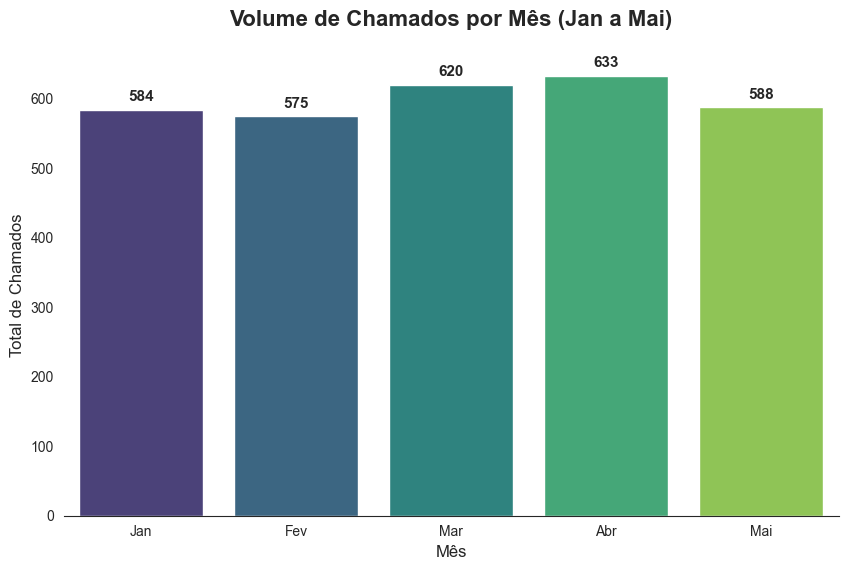

In [107]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração visual
plt.figure(figsize=(10, 6))
sns.set_style("white")

# Criando o gráfico de barras
# Usei uma paleta degradê para dar um toque mais profissional
cores = sns.color_palette("viridis", len(fluxo_atendimento))
barplot = sns.barplot(data=fluxo_atendimento, x='mês', y='qnt de chamados', palette=cores, hue="mês", legend=False)

# Adicionando os números em cima das barras para leitura imediata
for p in barplot.patches:
    barplot.annotate(format(p.get_height(), '.0f'), 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va = 'center', 
                   xytext = (0, 9), 
                   textcoords = 'offset points',
                   fontsize=11, fontweight='bold')

# Ajustando títulos e eixos
plt.title('Volume de Chamados por Mês (Jan a Mai)', fontsize=16, pad=20, fontweight='bold')
plt.xlabel('Mês', fontsize=12)
plt.ylabel('Total de Chamados', fontsize=12)
plt.xticks(ticks=range(len(fluxo_atendimento)), labels=['Jan', 'Fev', 'Mar', 'Abr', 'Mai'])

# Removendo bordas desnecessárias (estética "clean")
sns.despine(left=True, bottom=False)
plt.savefig('../imagens/volume_de_chamados_mensal.png')

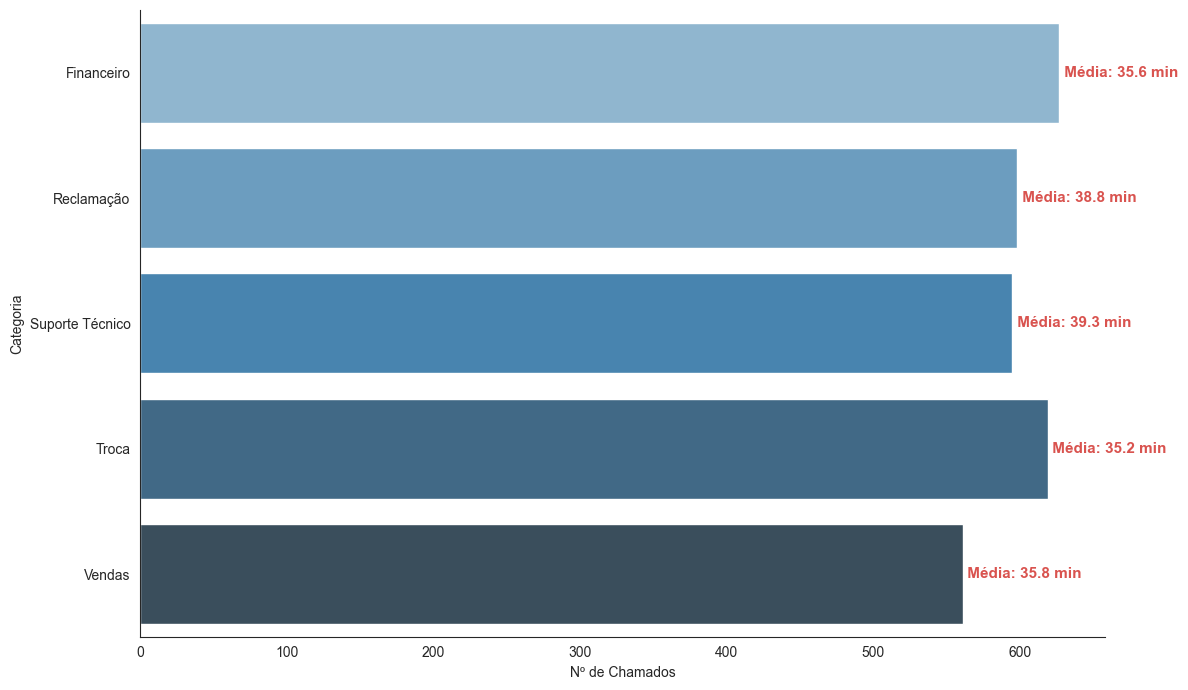

In [108]:
# Usando os dados de resumo_categoria criando anteriormente 

# Convertendo o Tempo Médio para minutos (número decimal)
if pd.api.types.is_timedelta64_dtype(resumo_categoria['Tempo Médio']):
    resumo_categoria['Tempo Médio Num'] = resumo_categoria['Tempo Médio'].dt.total_seconds() / 60
else:
    resumo_categoria['Tempo Médio Num'] = resumo_categoria['Tempo Médio']

fig, ax1 = plt.subplots(figsize=(12, 7))

# Gráfico de Barras para Quantidade
sns.barplot(data=resumo_categoria, y='Categoria', x='Nº de Chamados', ax=ax1, palette='Blues_d', hue='Categoria', legend=False)

# Adicionando o texto do Tempo Médio convertido
for i, row in resumo_categoria.iterrows():
    # coluna convertida para o texto
    ax1.text(row['Nº de Chamados'] + 0.5, i, 
             f" Média: {row['Tempo Médio Num']:.1f} min", 
             va='center', fontsize=11, fontweight='bold', color='#d9534f')

sns.despine(right=True, top=True)
plt.tight_layout()
plt.savefig('../imagens/categoria_tempo_medio.png')

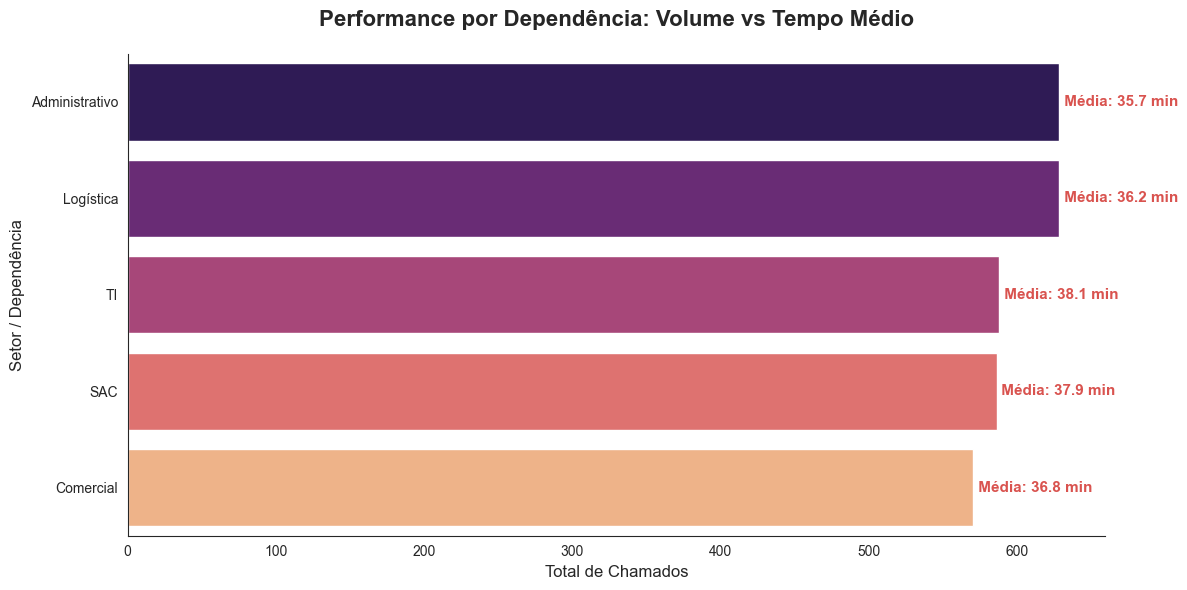

In [128]:
# Copiando a resolução dos dados colocando em uma variavel para criar o grafico
copia_resumo_dependencia = resumo_dependencia.copy()

# converte para minutos
if pd.api.types.is_timedelta64_dtype(copia_resumo_dependencia['Tempo Médio']):
    copia_resumo_dependencia['Tempo_Min'] = copia_resumo_dependencia['Tempo Médio'].dt.total_seconds() / 60
else:
    copia_resumo_dependencia['Tempo_Min'] = pd.to_numeric(copia_resumo_dependencia['Tempo Médio'], errors='coerce')

# Copiar as colunas de resumo_dependecia
copiar_dep = copia_resumo_dependencia.columns[0]  # 'Dependencia'
copiar_qnt = copia_resumo_dependencia.columns[1]  # 'Qnt de Denpendencia'

# criando a figura
plt.figure(figsize=(12, 6))

# Gráfico de Barras Horizontais
ax = sns.barplot(
    data=copia_resumo_dependencia.sort_values(copiar_qnt, ascending=False), 
    y=copiar_dep, 
    x=copiar_qnt, 
    palette='magma',
    hue=copiar_dep,
    legend=False
)

# Adicionando o rótulo de Tempo Médio ao lado das barras
for i, row in copia_resumo_dependencia.sort_values(copiar_qnt, ascending=False).reset_index(drop=True).iterrows():
    ax.text(
        row[copiar_qnt] + 0.5, i, 
        f" Média: {row['Tempo_Min']:.1f} min", 
        va='center', fontsize=11, fontweight='bold', color='#d9534f'
    )

# Estilização
plt.title('Performance por Dependência: Volume vs Tempo Médio', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Total de Chamados', fontsize=12)
plt.ylabel('Setor / Dependência', fontsize=12)
sns.despine(right=True, top=True)

plt.tight_layout()
plt.savefig('../imagens/dependencia_qnt_tempo.png')

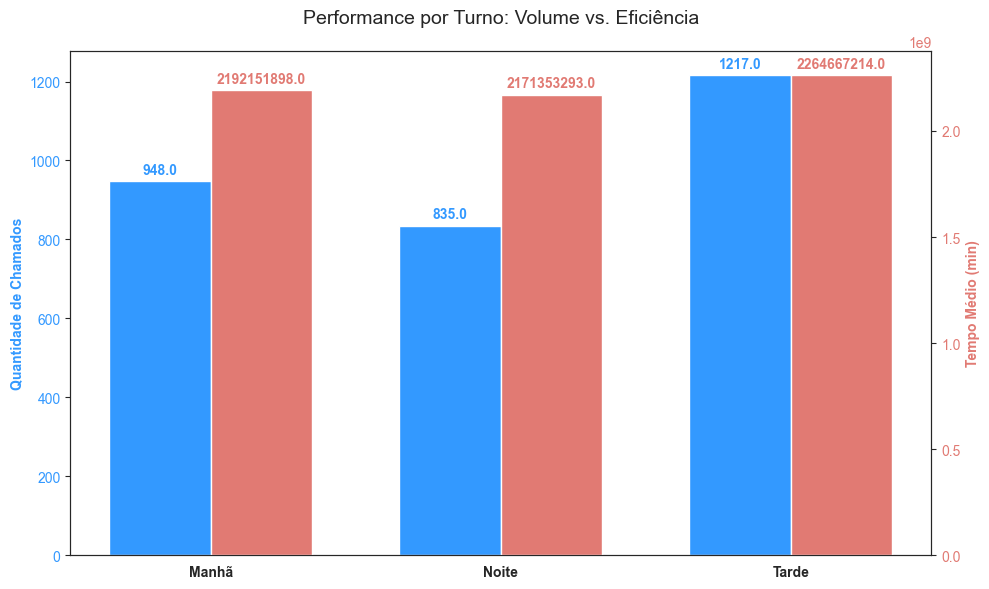

In [121]:
import numpy as np

# Converter as variaveis criando anteriormente para numérico
resumo_turno['Quantidade'] = pd.to_numeric(resumo_turno['Quantidade'], errors='coerce')
resumo_turno['Tempo_Medio'] = pd.to_numeric(resumo_turno['Tempo_Medio'], errors='coerce')

labels = resumo_turno['Turno']
qtd = resumo_turno['Quantidade']
tempo = resumo_turno['Tempo_Medio']

x = np.arange(len(labels))
width = 0.35

fig, ax1 = plt.subplots(figsize=(10, 6))

# Barras de Quantidade
rects1 = ax1.bar(x - width/2, qtd, width, label='Quantidade', color='#3399FF')
ax1.set_ylabel('Quantidade de Chamados', color='#3399FF', fontweight='bold')
ax1.tick_params(axis='y', labelcolor='#3399FF')

# Eixo secundário para Tempo Médio
ax2 = ax1.twinx()
rects2 = ax2.bar(x + width/2, tempo, width, label='Tempo Médio', color='#E17A73')
ax2.set_ylabel('Tempo Médio (min)', color='#E17A73', fontweight='bold')
ax2.tick_params(axis='y', labelcolor='#E17A73')

# Função de rótulos em float)
def autolabel(rects, ax, color):
    for rect in rects:
        height = rect.get_height()
        # Convertemos para float aqui para evitar o erro de formatação
        val = float(height)
        ax.annotate(f'{val:.1f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', color=color, fontweight='bold')

autolabel(rects1, ax1, '#3399FF')
autolabel(rects2, ax2, '#E17A73')

# 4. Ajustes Finais
plt.title('Performance por Turno: Volume vs. Eficiência', fontsize=14, pad=20)
ax1.set_xticks(x)
ax1.set_xticklabels(labels, fontweight='bold')
ax1.grid(False)
ax2.grid(False)

plt.tight_layout()
plt.savefig('../imagens/turno_tempo_medio.png')


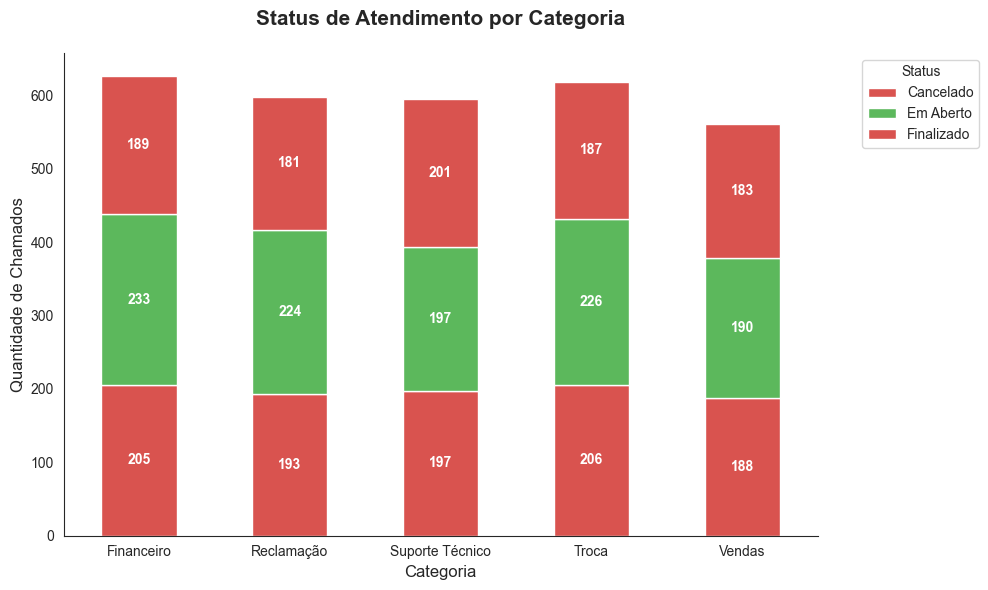

In [122]:
# Pegando a coluna categorias e status do arquivo
status_categoria = pd.crosstab(dados['categoria'], dados['status'])

#  Criando o gráfico de barras
ax = status_categoria.plot(kind='bar', 
                           stacked=True, 
                           figsize=(10, 6), 
                           color=['#d9534f', '#5cb85c']) # Vermelho para Aberto, Verde para Finalizado

# Adicionando rótulos de dados dentro das barras
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    if height > 0: # Só coloca número se o valor for maior que zero
        x, y = p.get_xy() 
        ax.text(x + width/2, 
                y + height/2, 
                f'{int(height)}', 
                ha='center', 
                va='center', 
                color='white', 
                fontweight='bold')

# Estilização
plt.title('Status de Atendimento por Categoria', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Categoria', fontsize=12)
plt.ylabel('Quantidade de Chamados', fontsize=12)
plt.xticks(rotation=0) # Deixa os nomes das categorias retos
plt.legend(title='Status', bbox_to_anchor=(1.05, 1), loc='upper left')

sns.despine()
plt.tight_layout()
plt.savefig('../imagens/qnt_status_categoria.png')

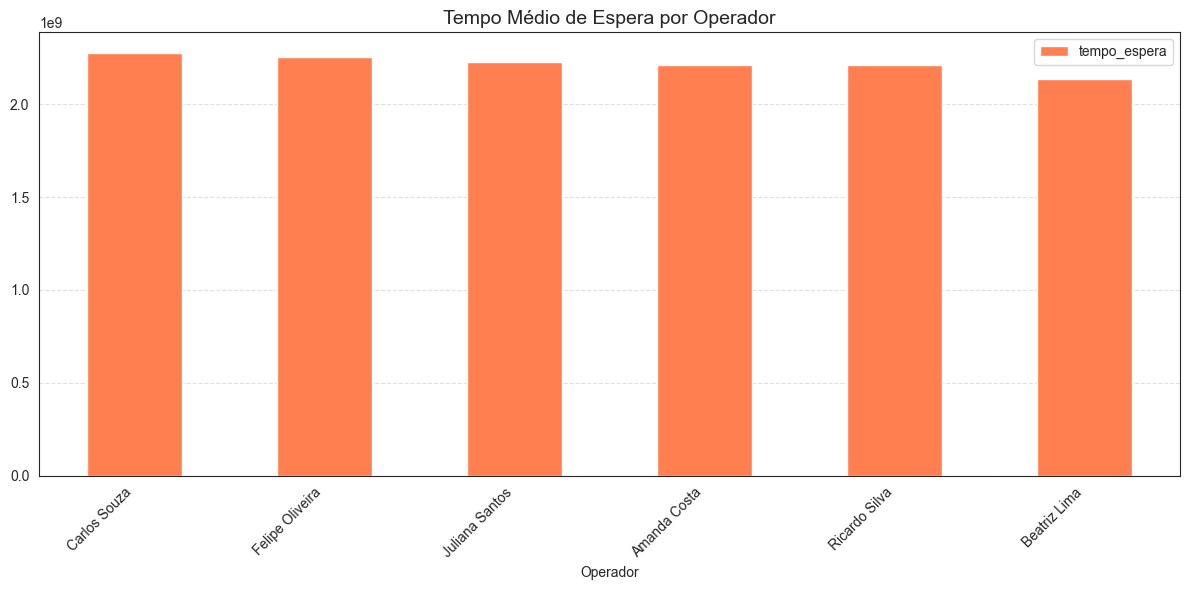

In [123]:
# relacionando operador com tempo_espera

# 1. Calculando a média de espera por operador
# (Mantendo o nome da variável que você iniciou, mas ajustando para 'operador')
espera_por_operador = dados.groupby('operador')['tempo_espera'].mean().sort_values(ascending=False)

# 2. Criando o gráfico
plt.figure(figsize=(12, 6))
espera_por_operador.plot(kind="bar", color="coral")

# 3. Customização
plt.title("Tempo Médio de Espera por Operador", fontsize=14)
plt.xlabel("Operador")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.savefig('../imagens/operador_tempo_medio.png')

RELATÓRIO


In [139]:
from reportlab.platypus.tables import TableStyle
from reportlab.platypus import (SimpleDocTemplate, Paragraph, Spacer, Image, Table)
from reportlab.lib.pagesizes import A4
from reportlab.lib import colors
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from datetime import datetime

# =========================
# DADOS FIXO DO RELATÓRIO
# =========================
empresa = "Morangos Tech"
nome = "Kariohana Araújo"
departamento = "Suporte Técnico"
periodo_analisado = "Últimos 4 meses"

# =========================
# ESTILOS
# =========================
styles = getSampleStyleSheet()
styles.add(ParagraphStyle(
    name="Justificado",
    alignment=4,
    spaceAfter=10
))

# =========================
# PROCESSANDO DADOS
# =========================

# 1 - processando chamados 
total_chamados = len(dados)
chamados_concluidos = len(dados[dados["status"] == "Finalizado"])
chamados_abertos = len(dados[dados['status'] == "Em Aberto"])
taxa_resolucao = (chamados_concluidos / total_chamados * 100) if total_chamados > 0 else 0

# 2 - processando operador

resumo_operador = (dados.groupby(['operador', 'status'])).size().reset_index(name='quantidade')

tabela_operador = (resumo_operador.pivot(index='operador', columns='status', values='quantidade')).fillna(0)
tabela_operador['Total de Atendimento'] = tabela_operador.sum(axis=1)

# =========================
# GARGALOS
# =========================
maior_categoria = (
    dados.groupby("categoria")["tempo_espera"]
    .mean()
    .idxmax()
)

maior_dependencia = (
    dados.groupby("dependencia")["tempo_espera"]
    .mean()
    .sort_values(ascending=False)
    .index[0]
)

maior_turno = (
    dados.groupby("turno")["tempo_espera"]
    .mean()
    .sort_values(ascending=False)
    .index[0]
)

# =========================
# CRIAÇÃO DO PDF
# =========================
arquivo = "../relatorio/relatorio_suporte_tecnico.pdf"
doc = SimpleDocTemplate(
    arquivo,
    pagesize=A4,
    rightMargin=40,
    leftMargin=40,
    topMargin=40,
    bottomMargin=40
)

story = []

# =========================
# CAPA
# =========================
story.append(Paragraph(
    "Relatório de Análise de Gargalos de Atendimento",
    styles["Title"]
))
story.append(Spacer(1, 20))

story.append(Paragraph(f"<b>Empresa:</b> {empresa}", styles["Normal"]))
story.append(Paragraph(f"<b>Responsável:</b> {nome}", styles["Normal"]))
story.append(Paragraph(f"<b>Departamento:</b> {departamento}", styles["Normal"]))
story.append(Paragraph(f"<b>Período analisado:</b> {periodo_analisado}", styles["Normal"]))

story.append(Spacer(1, 30))

# =========================
# CONTEXTO DO NEGÓCIO
# =========================
story.append(Paragraph("1. Contexto do Negócio", styles["Heading2"]))
story.append(Spacer(1, 8))

story.append(Paragraph("""
A Morangos Tech atua com soluções tecnológicas para mercados autônomos, oferecendo
sistemas de pagamento, controle de estoque, monitoramento e suporte operacional.

Como o produto impacta diretamente a operação do cliente, falhas e indisponibilidades
geram alto volume de contato com o suporte, tornando o atendimento um ponto crítico
da experiência do usuário.

Este relatório tem como objetivo identificar gargalos no atendimento e apoiar
decisões estratégicas baseadas em dados.
""", styles["Justificado"]))

# =========================
# RESUMO GERAL
# =========================
story.append(Spacer(1, 20))
story.append(Paragraph("Visão Geral dos Atendimentos", styles["Heading2"]))
story.append(Spacer(1, 8))

story.append(Image("../imagens/volume_de_chamados_mensal.png", width=480, height=230))
story.append(Spacer(1, 8))

story.append(Paragraph(
    f"""
Durante o período analisado, foram registrados <b>{total_chamados}</b> chamados.
Desse total, <b>{chamados_concluidos}</b> foram concluídos, resultando em uma
taxa de resolução de <b>{taxa_resolucao:.2f}%</b>.
    """,
    styles["Justificado"]
))
# =========================
# GARGALO POR OPERADOR
# =========================
story.append(Spacer(1, 25))
story.append(Paragraph("Indicadores por Operador", styles["Heading2"]))
story.append(Spacer(1, 10))

tabela_dados = [[
    'Operador', 'Finalizado', 'Em Aberto', 'Cancelado', 'Total de Atendimento'
]]

for operador, row in tabela_operador.iterrows():
    tabela_dados.append([
        operador,
        int(row.get("Finalizado", 0)),
        int(row.get("Em Aberto", 0)),
        int(row.get("Cancelado", 0)),
        int(row["Total de Atendimento"])
    ])

table = Table(tabela_dados, colWidths=[100, 70, 70, 70, 120])
table.setStyle(TableStyle([
    ("BACKGROUND", (0, 0), (-1, 0), colors.lightgrey),
    ("GRID", (0, 0), (-1, -1), 0.5, colors.grey),
    ("FONT", (0, 0), (-1, 0), "Helvetica-Bold"),
    ("ALIGN", (1, 1), (-1, -1), "CENTER"),
]))

story.append(table)
story.append(Spacer(1, 10))

story.append(Paragraph(f"""
No período analisado, foram registrados {total_chamados}, dos quais {chamados_concluidos} foram concluídos, representando aproximadamente {taxa_resolucao:.2f}% de resolução, enquanto
{chamados_abertos} chamados permanecem em aberto, em acompanhamento junto ao time de SAC. 

Segue abaixo o gráfico representando o tempo médio de atendimentos de cada operador.
""",  styles["Justificado"]))

story.append(Image('../imagens/operador_tempo_medio.png', width=480, height=230))
story.append(Spacer(1, 8))


# =========================
# GARGALO POR CATEGORIA
# =========================
story.append(Spacer(1, 20))
story.append(Paragraph("Gargalos por Categoria de Atendimento", styles["Heading2"]))
story.append(Spacer(1, 8))

story.append(Image("../imagens/categoria_tempo_medio.png", width=480, height=230))
story.append(Spacer(1, 8))

story.append(Paragraph(
    f"""
A categoria <b>{maior_categoria}</b> apresenta o maior tempo médio de atendimento,
indicando maior complexidade operacional e maior número de interações necessárias
para resolução.

Em empresas de mercados autônomos, reclamações estão frequentemente associadas a:<br/><br/>
• Falhas de pagamento<br/>
• Indisponibilidade do sistema<br/>
• Divergência de estoque<br/><br/>

Esse cenário indica oportunidades de melhoria tanto em processos internos quanto
na estabilidade do produto.
    """,
    styles["Justificado"]
))

# =========================
# GARGALO POR DEPENDÊNCIA
# =========================
story.append(Spacer(1, 20))
story.append(Paragraph("Gargalo por Dependência (Setor)", styles["Heading2"]))
story.append(Spacer(1, 8))

story.append(Image("../imagens/dependencia_qnt_tempo.png", width=480, height=230))
story.append(Spacer(1, 8))

story.append(Paragraph(
    f"""
O setor <b>{maior_dependencia}</b> concentra os atendimentos com maior tempo médio,
atuando como principal ponto de retenção dos chamados.

Isso indica que chamados complexos estão chegando sem triagem adequada, fazendo com
que o setor acumule funções além do atendimento inicial, reduzindo a eficiência
do fluxo operacional.
    """,
    styles["Justificado"]
))

# =========================
# GARGALO POR TURNO
# =========================
story.append(Spacer(1, 20))
story.append(Paragraph("Gargalo por Turno de Atendimento", styles["Heading2"]))
story.append(Spacer(1, 8))

story.append(Image("../imagens/turno_tempo_medio.png", width=480, height=230))
story.append(Spacer(1, 8))

story.append(Paragraph(
    f"""
O turno <b>{maior_turno}</b> apresenta o maior tempo médio de atendimento, indicando
desequilíbrio entre demanda e capacidade operacional.

Esse padrão sugere necessidade de revisão de escalas, redistribuição de recursos
humanos e priorização de chamados críticos nesse período.
    """,
    styles["Justificado"]
))

# =========================
# CONSIDERAÇÕES FINAIS
# =========================
story.append(Spacer(1, 30))
story.append(Paragraph("Considerações Finais", styles["Heading2"]))
story.append(Spacer(1, 10))

story.append(Paragraph(
    """
A análise dos dados evidencia que os gargalos de atendimento da Morangos Tech não
estão relacionados apenas ao volume de chamados, mas à concentração de casos
complexos em setores e períodos específicos.

Com melhorias na triagem, redistribuição de recursos e ajustes de processo,
é possível reduzir o tempo médio de atendimento, melhorar a experiência do cliente
e aumentar a eficiência operacional.
    """,
    styles["Justificado"]
))

story.append(Spacer(1, 40))

story.append(Paragraph(
    f"""
    <b>Data de emissão:</b> {datetime.now().strftime("%d/%m/%Y")}<br/>
    <b>Responsável pela análise:</b> {nome}
    """,
    styles["Normal"]
))

In [140]:
from reportlab.lib.units import cm

# =========================
# RODAPÉ
# =========================#

def rodape(canvas, doc):
    canvas.saveState()

    texto_esquerda = "Relatório de Suporte Técnico • Morangos Tech"
    texto_direita = f"Página {doc.page}"

    canvas.setFont("Helvetica", 9)

    # Linha separadora
    canvas.setStrokeColor(colors.grey)
    canvas.line(2*cm, 2*cm, 19*cm, 2*cm)

    # Texto
    canvas.drawString(2*cm, 1.5*cm, texto_esquerda)
    canvas.drawRightString(19*cm, 1.5*cm, texto_direita)

    canvas.restoreState()

# =========================
# GERAR RELATÓRIO
# =========================
doc.build(
    story,
    onFirstPage=rodape,
    onLaterPages=rodape
)